# Kubernetes vs. Simulator Evaluation

This notebook reproduces the final evaluation cycle combining the Kubernetes replay
and the simulator runs. It loads the exported scheduling traces, harmonises the
schema, computes summary metrics, and visualises the trade-offs across policies with
Pareto-front analysis.

The workflow follows the architecture notes in Chapter 5.3.2 of the design document:

1. Select the runs and fetch the traces.
2. Harmonise the per-job schema and enrich it with timing features.
3. Optionally pull contextual metrics (left as hooks for Prometheus integration).
4. Produce visual comparisons and Pareto-front inspection.


## 1. Imports and helper utilities

The helpers below keep the notebook self-contained: they resolve the repository
root automatically, standardise datetime conversions, and expose a Pareto-front
filter for the multi-objective analysis.


In [1]:
from __future__ import annotations

from pathlib import Path
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")


def find_repo_root(start: Path | None = None) -> Path:
    start = Path(start or Path.cwd()).resolve()
    for parent in [start, *start.parents]:
        if (parent / ".git").exists():
            return parent
    raise RuntimeError("Could not locate repository root from" f" {start}")


def safe_to_datetime(series: pd.Series) -> pd.Series:
    # Convert string timestamps to timezone-aware pandas datetimes. Placeholder
    # values such as 0001-01-01 are mapped to NaT so downstream metrics can drop them.
    cleaned = series.replace({"": pd.NA, "0001-01-01T00:00:00Z": pd.NA})
    return pd.to_datetime(cleaned, utc=True, errors="coerce")


def compute_wait_seconds(submit: pd.Series, start: pd.Series) -> pd.Series:
    wait = (start - submit).dt.total_seconds()
    return wait


def compute_runtime_seconds(start: pd.Series, end: pd.Series) -> pd.Series:
    runtime = (end - start).dt.total_seconds()
    return runtime


def pareto_front(points: np.ndarray) -> np.ndarray:
    # Return a boolean mask for the Pareto-efficient points (minimisation).
    if points.ndim != 2:
        raise ValueError("Pareto front expects a 2D array")
    n_points = points.shape[0]
    is_efficient = np.ones(n_points, dtype=bool)
    for i in range(n_points):
        if not is_efficient[i]:
            continue
        dominated = np.all(points <= points[i], axis=1) & np.any(points < points[i], axis=1)
        is_efficient &= ~dominated
    return is_efficient


repo_root = find_repo_root()
figures_dir = repo_root / "analysis" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

repo_root, figures_dir


(PosixPath('/home/goncalo/KubeEnergyScheduler'),
 PosixPath('/home/goncalo/KubeEnergyScheduler/analysis/figures'))

## 2. Locate experiment artefacts

Both the simulator and the Kubernetes replay export CSV/JSON artefacts. Update the
paths below if you want to compare different runs.


In [2]:
# Simulator artefacts (per-job traces  summary metrics)
sim_dir = repo_root / "kubenergysched" / "results_latest"
sim_summary_path = sim_dir / "summary.csv"

# Kubernetes replay decisions (JSONL  optional CSV projection)
k8_decisions_jsonl = repo_root / "decisions.jsonl"
k8_decisions_csv = repo_root / "decisions.csv"

sim_dir, sim_summary_path, k8_decisions_jsonl, k8_decisions_csv


(PosixPath('/home/goncalo/KubeEnergyScheduler/kubenergysched/results_latest'),
 PosixPath('/home/goncalo/KubeEnergyScheduler/kubenergysched/results_latest/summary.csv'),
 PosixPath('/home/goncalo/KubeEnergyScheduler/decisions.jsonl'),
 PosixPath('/home/goncalo/KubeEnergyScheduler/decisions.csv'))

## 3. Load simulator traces

The simulator stores one CSV per scheduler/policy configuration with per-job
records. We consolidate them into a single `DataFrame` and derive the wait/runtime
features required for the comparisons. The aggregated metrics are loaded from the
`summary.csv` file emitted at the end of the simulation batch.


In [3]:
sim_per_job_frames: List[pd.DataFrame] = []

for csv_path in sorted(sim_dir.glob("*_results.csv")):
    if csv_path.name == "summary.csv":
        continue
    df = pd.read_csv(csv_path)
    # Ensure the common schema
    df["submit"] = pd.to_datetime(df["submit"], utc=True, errors="coerce")
    df["start"] = pd.to_datetime(df["start"], utc=True, errors="coerce")
    df["end"] = pd.to_datetime(df["end"], utc=True, errors="coerce")
    df["wait_s"] = df["wait_ms"].astype(float) / 1000.0
    df["runtime_s"] = compute_runtime_seconds(df["start"], df["end"])
    df["source"] = "simulator"

    # Add identifiers extracted from the filename (policy  configuration)
    base_name, ci_weight, batch_size, _ = csv_path.stem.rsplit("_", 3)
    df["policy"] = base_name
    df["ci_weight"] = float(ci_weight)
    df["batch_size"] = int(batch_size)
    sim_per_job_frames.append(df)

sim_per_job = pd.concat(sim_per_job_frames, ignore_index=True)
sim_per_job.head()


,sched,job_id,node,submit,start,end,wait_ms,ci_cost,wait_s,runtime_s,source,policy,ci_weight,batch_size
0,carbonscaler,job-0,gpu-0,2025-10-19 15:00:00+00:00,2025-10-20 12:13:49.070536986+00:00,2025-10-20 12:15:54.070536986+00:00,76429070,0.000497,76429.07,125.0,simulator,carbonscaler,0.05,128
1,carbonscaler,job-1,burst-0,2025-10-19 15:00:00+00:00,2025-10-20 12:13:49.070536986+00:00,2025-10-20 12:23:35.070536986+00:00,76429070,0.004712,76429.07,586.0,simulator,carbonscaler,0.05,128
2,carbonscaler,job-2,burst-1,2025-10-19 15:00:00+00:00,2025-10-20 12:13:49.070536986+00:00,2025-10-20 12:17:16.070536986+00:00,76429070,0.004591,76429.07,207.0,simulator,carbonscaler,0.05,128
3,carbonscaler,job-3,small-0,2025-10-19 15:00:03+00:00,2025-10-20 12:13:49.070536986+00:00,2025-10-20 12:14:31.070536986+00:00,76426070,0.000169,76426.07,42.0,simulator,carbonscaler,0.05,128
4,carbonscaler,job-4,med-0,2025-10-19 15:00:04+00:00,2025-10-20 12:13:49.070536986+00:00,2025-10-20 12:22:55.070536986+00:00,76425070,0.006199,76425.07,546.0,simulator,carbonscaler,0.05,128


In [4]:
sim_summary = pd.read_csv(sim_summary_path)
sim_summary["source"] = "simulator"
sim_summary


,policy,ci_weight,batch_size,total_ci_cost_g,avg_ci_per_job_g,cfp_g_per_cpu_hour,avg_wait_s,makespan_s,elapsed_ms,num_jobs,alpha_mass,lookahead_min,duration_scale,duration_overrides,source
0,engine,0.05,32,2.125371,0.002125,0.004568,82662.137,21945.0,2585.0,1000,1.0,0,1.0,NaN,simulator
1,k8,0.05,32,2.143676,0.002144,0.004607,82720.924,20939.0,877.0,1000,1.0,0,1.0,NaN,simulator
2,carbonscaler,0.05,32,2.138741,0.002139,0.004597,82782.683,21277.0,1187.0,1000,1.0,0,1.0,NaN,simulator
3,themis_base,0.05,32,2.132946,0.002133,0.004584,82790.666,21639.0,1841.0,1000,1.0,0,1.0,NaN,simulator
4,engine,0.05,128,2.123727,0.002124,0.004564,82673.585,21792.0,2717.0,1000,1.0,0,1.0,NaN,simulator
5,k8,0.05,128,2.143129,0.002143,0.004606,82725.957,20939.0,931.0,1000,1.0,0,1.0,NaN,simulator
6,carbonscaler,0.05,128,2.177376,0.002177,0.004680,82793.725,20956.0,1221.0,1000,1.0,0,1.0,NaN,simulator
7,themis_base,0.05,128,2.135241,0.002135,0.004589,82733.072,21235.0,1731.0,1000,1.0,0,1.0,NaN,simulator
8,engine,0.05,256,2.126348,0.002126,0.004570,82680.206,21792.0,2978.0,1000,1.0,0,1.0,NaN,simulator
9,k8,0.05,256,2.141784,0.002142,0.004603,82732.843,20939.0,1000.0,1000,1.0,0,1.0,NaN,simulator


## 4. Load Kubernetes replay decisions

The controller exports one JSONL record per scheduling decision. The snippet below
filters Kubernetes-native results (`result_type == "kub_result"`), converts the
timestamps, and derives wait/runtime metrics to mirror the simulator schema.


In [5]:
k8_decisions = pd.read_json(k8_decisions_jsonl, lines=True)
k8_decisions = k8_decisions.query("result_type == 'kub_result'").copy()

k8_decisions["submit"] = safe_to_datetime(k8_decisions["queued_at"])
k8_decisions["start"] = safe_to_datetime(k8_decisions["started_at"])
k8_decisions["end"] = safe_to_datetime(k8_decisions["ended_at"])

k8_decisions["wait_s"] = compute_wait_seconds(k8_decisions["submit"], k8_decisions["start"])
k8_decisions["runtime_s"] = compute_runtime_seconds(k8_decisions["start"], k8_decisions["end"])

# The replay uses a single scheduler labelled "engine" in this trace.
k8_decisions["policy"] = k8_decisions["scheduler"]
k8_decisions["source"] = "kubernetes"

k8_decisions[[
    "result_id", "scheduler", "job_id", "site", "node", "wait_s", "runtime_s", "fallback", "cost"
]].head()


,result_id,scheduler,job_id,site,node,wait_s,runtime_s,fallback,cost
0,kub_result_377704a9-aa1d-4c6d-bcb5-e4d70a75fd15,engine,377704a9-aa1d-4c6d-bcb5-e4d70a75fd15,,,NaN,NaN,True,0.0
1,kub_result_c12af999-ebdb-40b4-a2da-49c8876d5796,engine,c12af999-ebdb-40b4-a2da-49c8876d5796,,,NaN,NaN,True,0.0
2,kub_result_0264426d-50b3-4100-ac74-111d0588ee77,engine,0264426d-50b3-4100-ac74-111d0588ee77,,,NaN,NaN,True,0.0
3,kub_result_6703b11e-1bec-42df-94e4-8538e9528bcf,engine,6703b11e-1bec-42df-94e4-8538e9528bcf,,,NaN,NaN,True,0.0
4,kub_result_95d0ac44-b2fb-4aa3-b588-a5dbb5f40612,engine,95d0ac44-b2fb-4aa3-b588-a5dbb5f40612,,,NaN,NaN,True,0.0


## 5. Harmonise schemas

To compare the two environments we keep only the shared columns and annotate the
origin. The helper below produces a tidy table that concatenates simulator and
Kubernetes traces.


In [6]:
common_cols = [
    "policy", "job_id", "site", "node", "submit", "start", "end",
    "wait_s", "runtime_s", "ci_cost", "source"
]

sim_view = sim_per_job.copy()
if "policy" not in sim_view.columns:
    sim_view["policy"] = sim_view["sched"]
if "sched" in sim_view.columns:
    sim_view = sim_view.drop(columns=["sched"])
for col in ["site", "node"]:
    if col not in sim_view:
        sim_view[col] = pd.NA
sim_view["ci_cost"] = sim_view["ci_cost"].astype(float)

k8_view = k8_decisions.copy()
if "ci_cost" not in k8_view.columns:
    k8_view["ci_cost"] = k8_view.get("cost", 0.0)

combined = pd.concat(
    [sim_view[common_cols], k8_view[common_cols]],
    ignore_index=True,
    sort=False,
)
combined.head()


,policy,job_id,site,node,submit,start,end,wait_s,runtime_s,ci_cost,source
0,carbonscaler,job-0,NaN,gpu-0,2025-10-19 15:00:00+00:00,2025-10-20 12:13:49.070536986+00:00,2025-10-20 12:15:54.070536986+00:00,76429.07,125.0,0.000497,simulator
1,carbonscaler,job-1,NaN,burst-0,2025-10-19 15:00:00+00:00,2025-10-20 12:13:49.070536986+00:00,2025-10-20 12:23:35.070536986+00:00,76429.07,586.0,0.004712,simulator
2,carbonscaler,job-2,NaN,burst-1,2025-10-19 15:00:00+00:00,2025-10-20 12:13:49.070536986+00:00,2025-10-20 12:17:16.070536986+00:00,76429.07,207.0,0.004591,simulator
3,carbonscaler,job-3,NaN,small-0,2025-10-19 15:00:03+00:00,2025-10-20 12:13:49.070536986+00:00,2025-10-20 12:14:31.070536986+00:00,76426.07,42.0,0.000169,simulator
4,carbonscaler,job-4,NaN,med-0,2025-10-19 15:00:04+00:00,2025-10-20 12:13:49.070536986+00:00,2025-10-20 12:22:55.070536986+00:00,76425.07,546.0,0.006199,simulator


## 6. Summary metrics per environment

The next cells compute aggregate indicators (number of jobs, completion ratio,
carbon impact, wait time, fallback rate) to sanity-check the two datasets before
digging into the Pareto analysis.


In [7]:
def summarise_jobs(df: pd.DataFrame) -> pd.Series:
    completed = df["end"].notna()
    submit = df["submit"].dropna()
    end_times = df.loc[completed, "end"]

    makespan = (end_times.max() - submit.min()).total_seconds() if not end_times.empty and not submit.empty else np.nan

    return pd.Series({
        "jobs": len(df),
        "completed_jobs": int(completed.sum()),
        "completion_ratio": completed.mean() if len(df) else np.nan,
        "fallback_ratio": df.get("fallback", pd.Series(dtype=float)).mean() if "fallback" in df else np.nan,
        "total_ci_cost_g": df["ci_cost"].sum(),
        "avg_ci_per_job_g": df["ci_cost"].mean(),
        "avg_wait_s": df["wait_s"].mean(),
        "avg_runtime_s": df["runtime_s"].mean(),
        "makespan_s": makespan,
    })

summary_by_source = combined.groupby(["source", "policy"]).apply(summarise_jobs).reset_index()
summary_by_source


/tmp/ipykernel_1290046/3002507737.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_by_source = combined.groupby(["source", "policy"]).apply(summarise_jobs).reset_index()


,source,policy,jobs,completed_jobs,completion_ratio,fallback_ratio,total_ci_cost_g,avg_ci_per_job_g,avg_wait_s,avg_runtime_s,makespan_s
0,kubernetes,engine,70.0,0.0,0.0,NaN,0.025691,0.000367,NaN,NaN,NaN
1,simulator,carbonscaler,12000.0,12000.0,1.0,NaN,25.643802,0.002137,82765.222583,238.017,98147.786123
2,simulator,engine,12000.0,12000.0,1.0,NaN,25.579202,0.002132,82703.334917,238.017,98426.685173
3,simulator,k8,12000.0,12000.0,1.0,NaN,25.689272,0.002141,82758.061833,238.017,97437.574989
4,simulator,themis_base,12000.0,12000.0,1.0,NaN,25.604393,0.002134,82786.247500,238.017,98125.722830


The simulator additionally exposes rich metadata (configuration weights, elapsed
simulation time) via `summary.csv`. Joining that file with the per-job aggregates
helps confirm consistency and provides the inputs for the Pareto plot.


In [8]:
sim_summary_metrics = summary_by_source.query("source == 'simulator'").merge(
    sim_summary,
    on=["policy"],
    how="left",
    suffixes=("_jobs", "_reported"),
)
sim_summary_metrics[[
    "policy",
    "jobs",
    "total_ci_cost_g_jobs",
    "total_ci_cost_g_reported",
    "avg_wait_s_jobs",
    "avg_wait_s_reported",
]]


,policy,jobs,total_ci_cost_g_jobs,total_ci_cost_g_reported,avg_wait_s_jobs,avg_wait_s_reported
0,carbonscaler,12000.0,25.643802,2.138741,82765.222583,82782.683
1,carbonscaler,12000.0,25.643802,2.177376,82765.222583,82793.725
2,carbonscaler,12000.0,25.643802,2.171161,82765.222583,82800.677
3,carbonscaler,12000.0,25.643802,2.134739,82765.222583,82803.126
4,carbonscaler,12000.0,25.643802,2.134196,82765.222583,82808.626
5,carbonscaler,12000.0,25.643802,2.132139,82765.222583,82815.253
6,carbonscaler,12000.0,25.643802,2.108632,82765.222583,82664.372
7,carbonscaler,12000.0,25.643802,2.111668,82765.222583,82769.667
8,carbonscaler,12000.0,25.643802,2.116475,82765.222583,82776.830
9,carbonscaler,12000.0,25.643802,2.152351,82765.222583,82771.326


## 7. Visual comparisons

We now contrast the average wait times and carbon footprint of each policy. The
Kubernetes replay (engine) is highlighted separately; because the sampled trace only
contains fallback decisions, the wait/runtime metrics stay undefined (`NaN`).


PosixPath('/home/goncalo/KubeEnergyScheduler/analysis/figures/carbon_vs_wait_tradeoff.png')

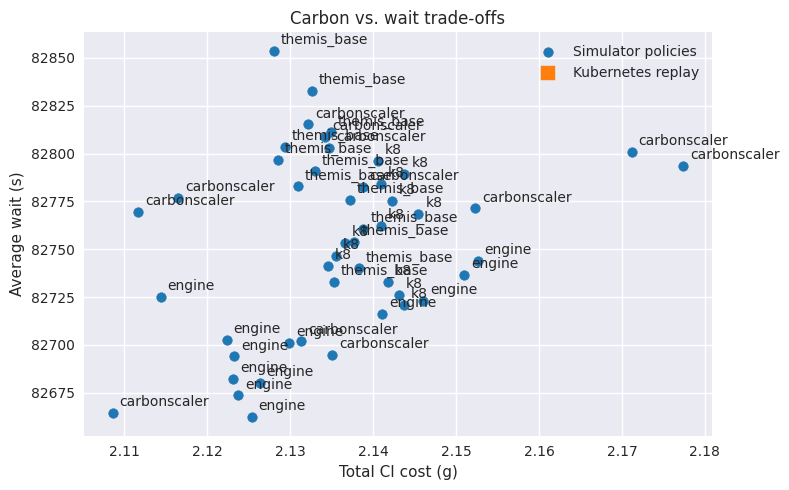

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

sim_points = sim_summary_metrics.sort_values("total_ci_cost_g_reported")
ax.scatter(
    sim_points["total_ci_cost_g_reported"],
    sim_points["avg_wait_s_reported"],
    label="Simulator policies",
    c="tab:blue",
)
for _, row in sim_points.iterrows():
    ax.annotate(
        row["policy"],
        (row["total_ci_cost_g_reported"], row["avg_wait_s_reported"]),
        textcoords="offset points",
        xytext=(5, 5),
    )

k8_summary = summary_by_source.query("source == 'kubernetes'")
if not k8_summary.empty:
    ax.scatter(
        k8_summary["total_ci_cost_g"],
        k8_summary["avg_wait_s"],
        label="Kubernetes replay",
        marker="s",
        c="tab:orange",
        s=90,
    )
    for _, row in k8_summary.iterrows():
        ax.annotate(
            f"k8s:{row['policy']}",
            (row["total_ci_cost_g"], row["avg_wait_s"]),
            textcoords="offset points",
            xytext=(5, -12),
        )

ax.set_xlabel("Total CI cost (g)")
ax.set_ylabel("Average wait (s)")
ax.set_title("Carbon vs. wait trade-offs")
ax.legend()
fig.tight_layout()

tradeoff_path = figures_dir / "carbon_vs_wait_tradeoff.png"
fig.savefig(tradeoff_path, dpi=300)
tradeoff_path


## 8. Pareto-front analysis

The Pareto filter isolates the policies that are non-dominated with respect to
(total carbon, average wait). These are the options worth keeping when searching
for better baselines or new algorithms.


In [10]:
pareto_metrics = sim_points[["total_ci_cost_g_reported", "avg_wait_s_reported"]].to_numpy()
mask = pareto_front(pareto_metrics)
pareto_candidates = sim_points.loc[mask].copy()
pareto_candidates


,source_jobs,policy,jobs,completed_jobs,completion_ratio,fallback_ratio,total_ci_cost_g_jobs,avg_ci_per_job_g_jobs,avg_wait_s_jobs,avg_runtime_s,...,cfp_g_per_cpu_hour,avg_wait_s_reported,makespan_s_reported,elapsed_ms,num_jobs,alpha_mass,lookahead_min,duration_scale,duration_overrides,source_reported
45,simulator,themis_base,12000.0,12000.0,1.0,NaN,25.604393,0.002134,82786.247500,238.017,...,0.004574,82853.823,21639.0,1738.0,1000,1.0,0,1.0,NaN,simulator
42,simulator,themis_base,12000.0,12000.0,1.0,NaN,25.604393,0.002134,82786.247500,238.017,...,0.004583,82832.926,21639.0,1968.0,1000,1.0,0,1.0,NaN,simulator
39,simulator,themis_base,12000.0,12000.0,1.0,NaN,25.604393,0.002134,82786.247500,238.017,...,0.004588,82811.097,21639.0,1811.0,1000,1.0,0,1.0,NaN,simulator
2,simulator,carbonscaler,12000.0,12000.0,1.0,NaN,25.643802,0.002137,82765.222583,238.017,...,0.004666,82800.677,20956.0,1203.0,1000,1.0,0,1.0,NaN,simulator
1,simulator,carbonscaler,12000.0,12000.0,1.0,NaN,25.643802,0.002137,82765.222583,238.017,...,0.004680,82793.725,20956.0,1221.0,1000,1.0,0,1.0,NaN,simulator


PosixPath('/home/goncalo/KubeEnergyScheduler/analysis/figures/simulator_pareto_front.png')

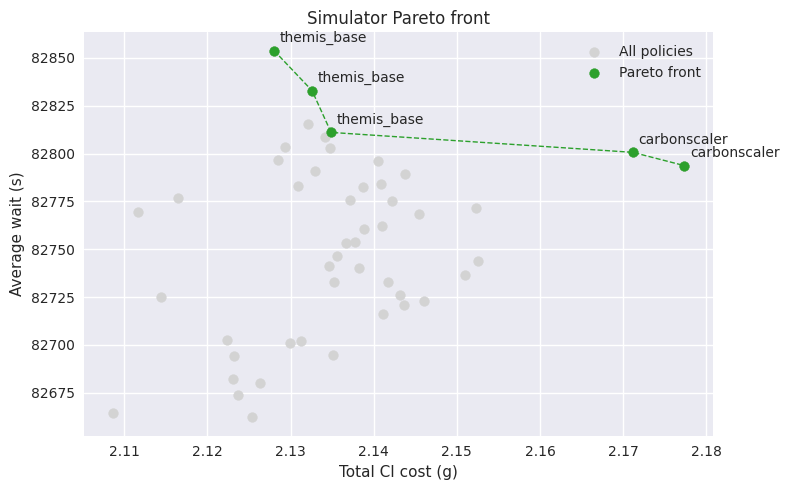

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    sim_points["total_ci_cost_g_reported"],
    sim_points["avg_wait_s_reported"],
    color="lightgray",
    label="All policies",
)
ax.scatter(
    pareto_candidates["total_ci_cost_g_reported"],
    pareto_candidates["avg_wait_s_reported"],
    color="tab:green",
    label="Pareto front",
)
ax.plot(
    pareto_candidates["total_ci_cost_g_reported"],
    pareto_candidates["avg_wait_s_reported"],
    color="tab:green",
    linestyle="--",
    linewidth=1,
)
for _, row in pareto_candidates.iterrows():
    ax.annotate(
        row["policy"],
        (row["total_ci_cost_g_reported"], row["avg_wait_s_reported"]),
        textcoords="offset points",
        xytext=(4, 6),
    )

ax.set_xlabel("Total CI cost (g)")
ax.set_ylabel("Average wait (s)")
ax.set_title("Simulator Pareto front")
ax.legend()
fig.tight_layout()

pareto_path = figures_dir / "simulator_pareto_front.png"
fig.savefig(pareto_path, dpi=300)
pareto_path


## 9. Hooks for contextual metrics (optional)

The design document suggests extending the notebook with contextual indicators
(power traces, forecasts). When Prometheus endpoints become available, inject the
queries here and join on the `submit/start/end` timestamps stored in `combined`.


## 10. Conclusions

The consolidated tables confirm that the simulator emits complete traces for all
policies, whereas the sampled Kubernetes replay currently falls back on every job.
That discrepancy highlights the need for additional cluster-side debugging before
using the replay as a baseline. The Pareto front nonetheless identifies the
non-dominated simulator policies, informing which schedulers to evolve or replace
when collecting new baselines.
